# DINO Training Metrics
Parse `OUTPUT_DINO/log.txt` and plot loss, learning rate, and weight decay over epochs.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

LOG_PATH = Path("OUTPUT_DINO_ITERATIVE/pass1_shape/log.txt")

records = []
with open(LOG_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records).sort_values("epoch").reset_index(drop=True)
print(f"Loaded {len(df)} epochs  |  columns: {list(df.columns)}")
df.head()

Loaded 49 epochs  |  columns: ['train_loss', 'train_lr', 'train_wd', 'epoch']


,train_loss,train_lr,train_wd,epoch
0,10.986466,0.000002,0.040007,0
1,10.678227,0.000005,0.040052,1
2,10.548261,0.000008,0.040140,2
3,10.794968,0.000011,0.040274,3
4,10.798098,0.000014,0.040451,4


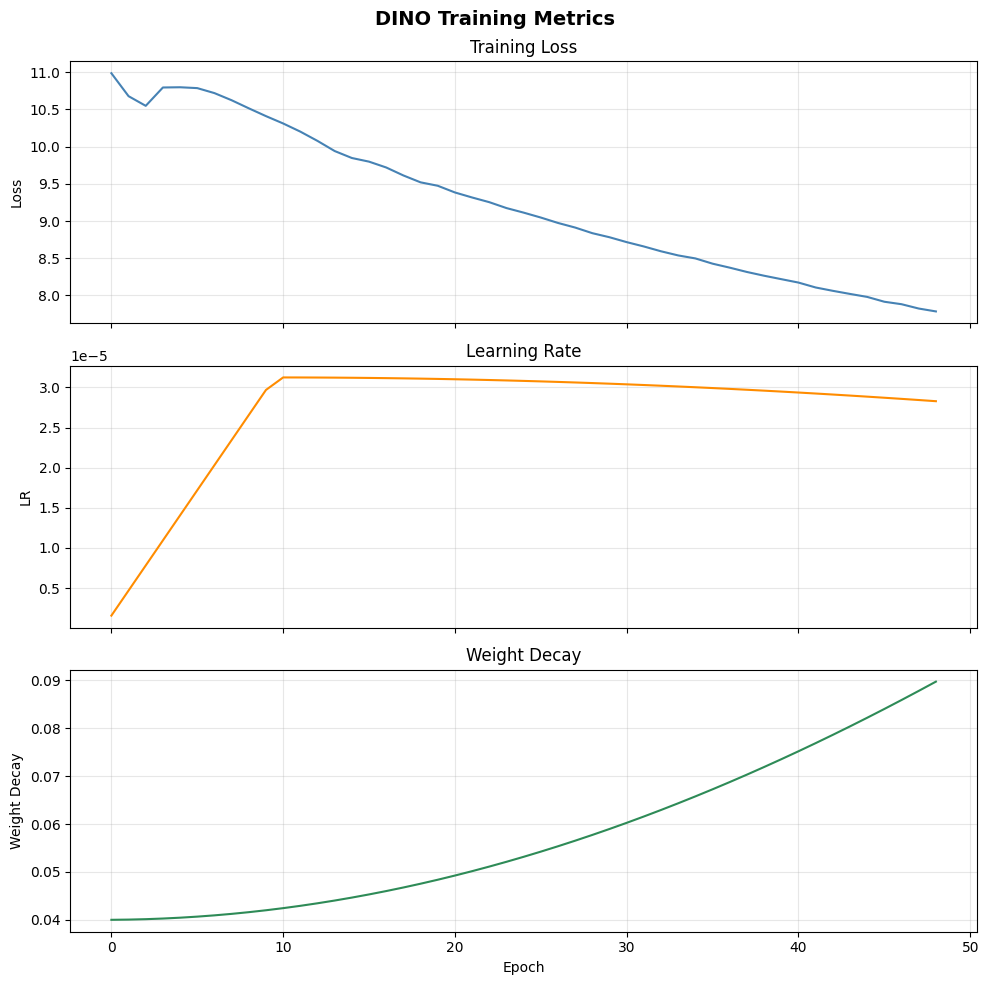

Plot saved to OUTPUT_DINO/training_metrics.png


In [2]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# --- Loss ---
axes[0].plot(df["epoch"], df["train_loss"], color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].grid(True, alpha=0.3)

# --- Learning Rate ---
axes[1].plot(df["epoch"], df["train_lr"], color="darkorange", linewidth=1.5)
axes[1].set_ylabel("LR")
axes[1].set_title("Learning Rate")
axes[1].grid(True, alpha=0.3)

# --- Weight Decay ---
axes[2].plot(df["epoch"], df["train_wd"], color="seagreen", linewidth=1.5)
axes[2].set_ylabel("Weight Decay")
axes[2].set_title("Weight Decay")
axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.3)

fig.suptitle("DINO Training Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig("OUTPUT_DINO/training_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to OUTPUT_DINO/training_metrics.png")

In [3]:
# Summary statistics
print(df[["train_loss", "train_lr", "train_wd"]].describe().round(6))

       train_loss    train_lr    train_wd
count  200.000000  200.000000  200.000000
mean     5.058436    0.000008    0.219999
std      2.345345    0.000005    0.127597
min      3.025752    0.000001    0.040007
25%      3.156317    0.000003    0.093225
50%      3.874766    0.000008    0.219999
75%      6.728064    0.000013    0.346774
max     10.924414    0.000016    0.399993
